# Machine Learning Project
# Data info and Model
# Kylle Waldie

## Imports

In [1]:
import pandas as pd

## Data Info

### Count of unique

In [2]:
def count_unique(file, column_header):
    data = pd.read_csv(file)

    return data[column_header].nunique()

file_path = 'psa_grades_images.csv'
grades = 'PSA_Grade'
nums_of_each = count_unique(file_path, grades)
print(nums_of_each)

17


### Count of each unique

In [3]:
data = pd.read_csv('psa_grades_images.csv')
count = data.value_counts()
print(count)

PSA_Grade  Image_URL                                                  
10         https://i.ebayimg.com/images/g/oBoAAeSwVsdo7yuo/s-l225.jpg     10
1          https://i.ebayimg.com/images/g/foYAAeSw0ntof7p-/s-l225.jpg      9
9          https://i.ebayimg.com/images/g/bM0AAOSwIKtoT-je/s-l225.jpg      8
           https://i.ebayimg.com/images/g/9NUAAeSwR8hpg~K1/s-l225.jpg      8
7          https://i.ebayimg.com/images/g/PagAAOSwoi1nGhll/s-l225.jpg      8
                                                                          ..
1          https://i.ebayimg.com/images/g/1~QAAeSwIQhppPDO/s-l1600.jpg     1
10         https://i.ebayimg.com/images/g/~JgAAeSwaWVpYQzF/s-l225.jpg      1
           https://i.ebayimg.com/images/g/~MEAAeSwnMRphDEg/s-l225.jpg      1
           https://i.ebayimg.com/images/g/~OoAAeSwlrFphAQo/s-l225.jpg      1
           https://i.ebayimg.com/images/g/~P4AAeSwEb5phB5~/s-l225.jpg      1
Name: count, Length: 26687, dtype: int64


In [4]:
# Read the CSV file into a DataFrame
df = pd.read_csv('psa_grades_images.csv')

column_name = 'PSA_Grade'

if column_name in df.columns:
    counts = df[column_name].value_counts()
    
    # Loop from 1 to 10
    for grade in range(1, 11):
        count = counts.get(grade, 0)
        print(f"{grade}'s: {count}")
else:
    print(f"Column '{column_name}' not found in the CSV file.")

1's: 335
2's: 88
3's: 1392
4's: 1749
5's: 3200
6's: 2641
7's: 6482
8's: 8224
9's: 9007
10's: 3164


# Models

### Imports

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    mean_squared_error
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

### Paths

In [6]:
DATASET_PATH = r"C:\Users\wldky\OneDrive - Montana Tech\Spring-2026\CSCI 447\ML Project\dataset\processed\dataset.npz"
OUTPUT_DIR   = r"C:\Users\wldky\OneDrive - Montana Tech\Spring-2026\CSCI 447\ML Project\dataset\results"

### Settings

In [7]:
RANDOM_SEED    = 42
PCA_COMPONENTS = 150  # Number of PCA components to reduce to before SVM
NN_EPOCHS      = 50   # Max training epochs for neural network
NN_BATCH_SIZE  = 32   # Batch size for neural network

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

## Load data

In [8]:
def load_data(path):
    """
    Load the preprocessed dataset from the .npz file.
    Returns both the full training set (for sklearn models) and the
    separate val set (for neural network early stopping).
    """
    print("Loading dataset...")
    data    = np.load(path)
    X_train = data['X_train']
    X_val   = data['X_val']
    X_test  = data['X_test']
    y_train = data['y_train']
    y_val   = data['y_val']
    y_test  = data['y_test']
 
    # Sklearn models use combined train+val
    X_train_full = np.concatenate([X_train, X_val])
    y_train_full = np.concatenate([y_train, y_val])
 
    print(f"  Training samples:   {len(X_train_full)}")
    print(f"  Validation samples: {len(X_val)}")
    print(f"  Test samples:       {len(X_test)}")
    print(f"  Features per image: {X_train.shape[1]:,}")
 
    return X_train_full, X_val, X_test, y_train_full, y_val, y_test

### Models and functions

In [9]:
def plot_confusion_matrix(y_true, y_pred, title, filename):
    """Plot and save a confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=[f'PSA {i}' for i in range(1, 11)],
        yticklabels=[f'PSA {i}' for i in range(1, 11)]
    )
    plt.title(title)
    plt.ylabel('True Grade')
    plt.xlabel('Predicted Grade')
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(save_path)
    plt.show()
    print(f"  Confusion matrix saved to: {save_path}")

In [10]:
def evaluate_classifier(name, y_true, y_pred):
    """Print accuracy and within-1-grade accuracy for a classifier."""
    accuracy   = accuracy_score(y_true, y_pred)
    within_one = np.mean(np.abs(y_true - y_pred) <= 1)
 
    print(f"\n{'='*45}")
    print(f"Results: {name}")
    print(f"{'='*45}")
    print(f"  Exact accuracy:   {accuracy*100:.1f}%")
    print(f"  Within 1 grade:   {within_one*100:.1f}%")
    print(f"\nClassification Report:")
    print(classification_report(
        y_true, y_pred,
        target_names=[f'PSA {i}' for i in range(1, 11)],
        zero_division=0
    ))
    return accuracy, within_one

In [11]:
def evaluate_regressor(name, y_true, y_pred_raw):
    """Print RMSE and within-1-grade accuracy for a regressor."""
    y_pred_rounded = np.clip(np.round(y_pred_raw).astype(int), 1, 10)
    rmse       = np.sqrt(mean_squared_error(y_true, y_pred_raw))
    accuracy   = accuracy_score(y_true, y_pred_rounded)
    within_one = np.mean(np.abs(y_true - y_pred_rounded) <= 1)
 
    print(f"\n{'='*45}")
    print(f"Results: {name}")
    print(f"{'='*45}")
    print(f"  RMSE:             {rmse:.3f} grades")
    print(f"  Exact accuracy:   {accuracy*100:.1f}%")
    print(f"  Within 1 grade:   {within_one*100:.1f}%")
    print(f"\nClassification Report (rounded predictions):")
    print(classification_report(
        y_true, y_pred_rounded,
        target_names=[f'PSA {i}' for i in range(1, 11)],
        zero_division=0
    ))
    return y_pred_rounded, accuracy, within_one

In [12]:
def plot_training_history(history, filename):
    """Plot neural network training and validation accuracy/loss over epochs."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0].set_title('Neural Network Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
 
    # Loss
    axes[1].plot(history.history['loss'],     label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title('Neural Network Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
 
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(save_path)
    plt.show()
    print(f"  Training history saved to: {save_path}")

In [13]:
def plot_model_comparison(results):
    """Bar chart comparing all four models."""
    models     = [r['name'] for r in results]
    accuracies = [r['accuracy'] for r in results]
    within_one = [r['within_one'] for r in results]
 
    x     = np.arange(len(models))
    width = 0.35
 
    fig, ax = plt.subplots(figsize=(12, 6))
    bars1 = ax.bar(x - width/2, accuracies, width, label='Exact Accuracy',  color='steelblue')
    bars2 = ax.bar(x + width/2, within_one,  width, label='Within 1 Grade', color='lightgreen')
 
    ax.set_ylabel('Accuracy')
    ax.set_title('Model Comparison: PSA Grade Prediction')
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.legend()
    ax.set_ylim(0, 1.0)
 
    for bar in bars1:
        ax.annotate(f'{bar.get_height()*100:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 3), textcoords="offset points", ha='center')
    for bar in bars2:
        ax.annotate(f'{bar.get_height()*100:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 3), textcoords="offset points", ha='center')
 
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, 'model_comparison.png')
    plt.savefig(save_path)
    plt.show()
    print(f"Comparison chart saved to: {save_path}")

In [14]:
def build_neural_network(input_dim, num_classes=10):
    """
    Build a simple MLP neural network.
 
    Architecture (Chapter 10 of your textbook):
        Input layer  → 150,528 pixel features
        Dense 512    → ReLU activation
        Dropout 30%  → prevents overfitting
        Dense 256    → ReLU activation
        Dropout 30%  → prevents overfitting
        Dense 128    → ReLU activation
        Output 10    → Softmax (one probability per PSA grade)
    """
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name='PSA_Grade_MLP')
 
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
 
    return model

## Run Functions

Loading dataset...
  Training samples:   6487
  Validation samples: 1145
  Test samples:       1145
  Features per image: 150,528

Training Random Forest Classifier...
(This may take a few minutes)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   12.7s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   40.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished



Results: Random Forest Classifier
  Exact accuracy:   51.0%
  Within 1 grade:   76.3%

Classification Report:
              precision    recall  f1-score   support

       PSA 1       0.00      0.00      0.00         7
       PSA 2       1.00      0.25      0.40         4
       PSA 3       1.00      0.27      0.42        56
       PSA 4       0.88      0.23      0.36        61
       PSA 5       0.55      0.27      0.36       131
       PSA 6       0.76      0.18      0.29        73
       PSA 7       0.46      0.62      0.53       264
       PSA 8       0.44      0.65      0.53       284
       PSA 9       0.59      0.67      0.63       218
      PSA 10       1.00      0.21      0.35        47

    accuracy                           0.51      1145
   macro avg       0.67      0.34      0.39      1145
weighted avg       0.58      0.51      0.49      1145



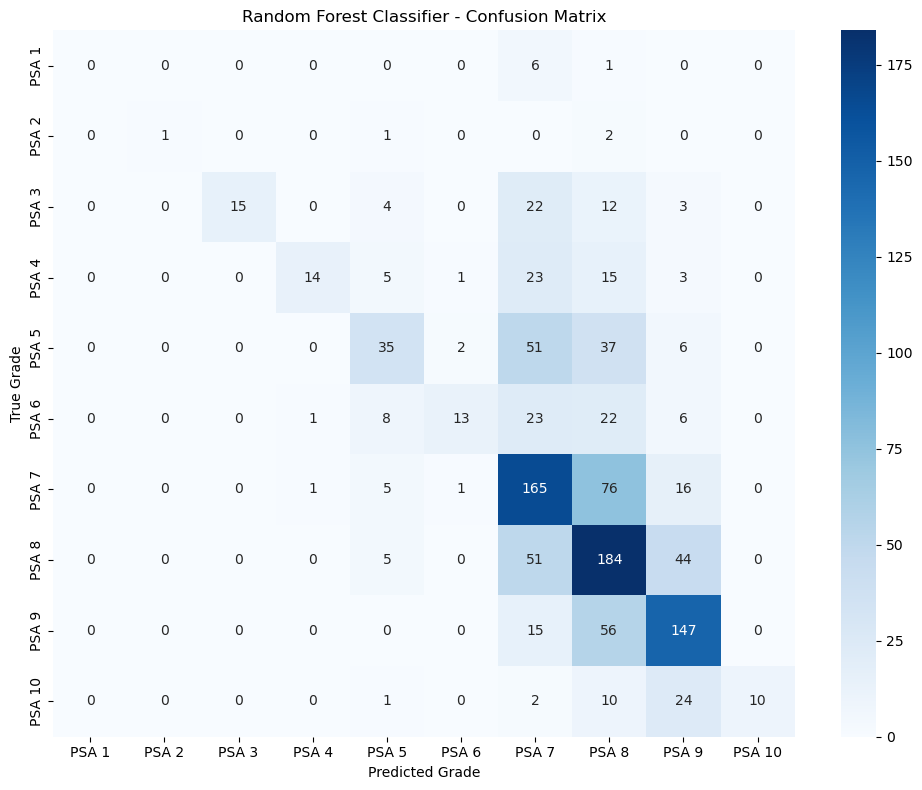

  Confusion matrix saved to: C:\Users\wldky\OneDrive - Montana Tech\Spring-2026\CSCI 447\ML Project\dataset\results\rf_classifier_confusion.png

Training PCA (150 components) + SVM Classifier...
(This will take longer — SVM is slow on large datasets)

Results: PCA + SVM Classifier
  Exact accuracy:   52.9%
  Within 1 grade:   75.0%

Classification Report:
              precision    recall  f1-score   support

       PSA 1       0.00      0.00      0.00         7
       PSA 2       1.00      0.50      0.67         4
       PSA 3       0.49      0.38      0.42        56
       PSA 4       0.52      0.43      0.47        61
       PSA 5       0.47      0.44      0.46       131
       PSA 6       0.37      0.36      0.36        73
       PSA 7       0.52      0.58      0.55       264
       PSA 8       0.54      0.60      0.57       284
       PSA 9       0.59      0.62      0.61       218
      PSA 10       0.70      0.34      0.46        47

    accuracy                           0.53   

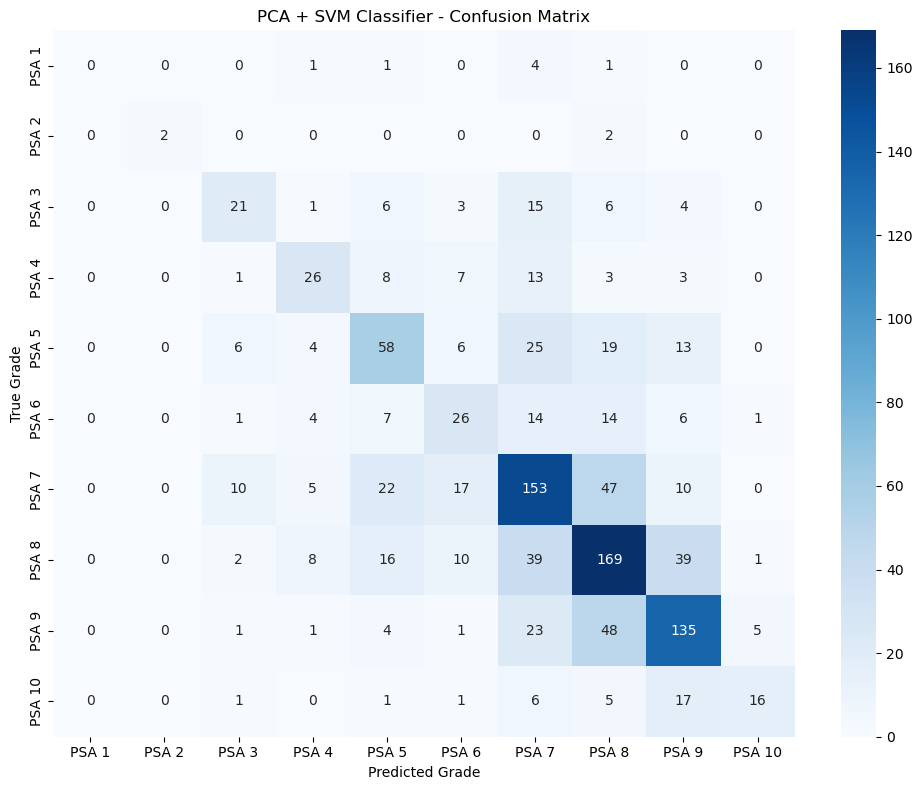

  Confusion matrix saved to: C:\Users\wldky\OneDrive - Montana Tech\Spring-2026\CSCI 447\ML Project\dataset\results\svm_confusion.png

Training PCA (150 components) + Random Forest Regressor...
(PCA reduces features first so this runs much faster)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    6.3s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   19.5s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished



Results: PCA + RF Regressor
  RMSE:             1.479 grades
  Exact accuracy:   28.2%
  Within 1 grade:   72.2%

Classification Report (rounded predictions):
              precision    recall  f1-score   support

       PSA 1       0.00      0.00      0.00         7
       PSA 2       0.00      0.00      0.00         4
       PSA 3       0.00      0.00      0.00        56
       PSA 4       0.13      0.03      0.05        61
       PSA 5       0.33      0.09      0.14       131
       PSA 6       0.12      0.49      0.20        73
       PSA 7       0.29      0.49      0.36       264
       PSA 8       0.36      0.37      0.37       284
       PSA 9       0.67      0.17      0.27       218
      PSA 10       0.00      0.00      0.00        47

    accuracy                           0.28      1145
   macro avg       0.19      0.17      0.14      1145
weighted avg       0.34      0.28      0.26      1145



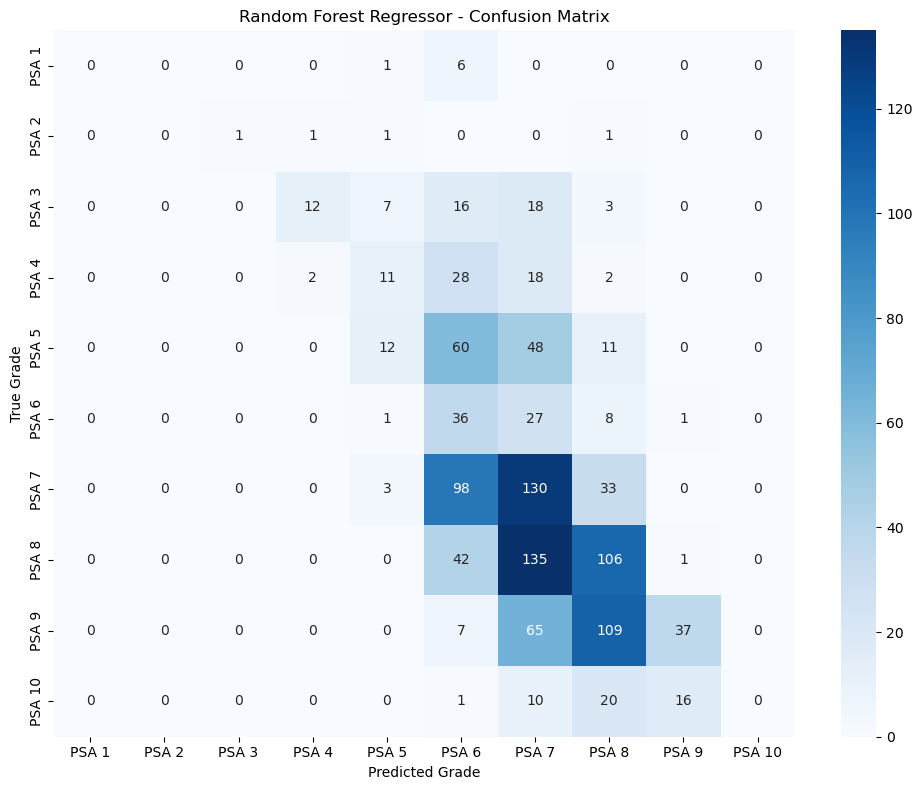

  Confusion matrix saved to: C:\Users\wldky\OneDrive - Montana Tech\Spring-2026\CSCI 447\ML Project\dataset\results\rf_regressor_confusion.png

Training Neural Network (MLP)...
(Uses validation set for early stopping)


Model: "PSA_Grade_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │    77,070,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,236,362 (294.63 MB)

 Trainable params: 77,236,362 (294.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 132s 636ms/step - accuracy: 0.2092 - loss: 10.1446 - val_accuracy: 0.2288 - val_loss: 2.0427
Epoch 2/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 120s 589ms/step - accuracy: 0.2325 - loss: 1.9706 - val_accuracy: 0.2306 - val_loss: 1.9296
Epoch 3/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 117s 575ms/step - accuracy: 0.2417 - loss: 1.9234 - val_accuracy: 0.2480 - val_loss: 1.9149
Epoch 4/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 117s 577ms/step - accuracy: 0.2416 - loss: 1.9162 - val_accuracy: 0.2480 - val_loss: 1.9115
Epoch 5/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 123s 608ms/step - accuracy: 0.2502 - loss: 1.9143 - val_accuracy: 0.2480 - val_loss: 1.9105
Epoch 6/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 123s 606ms/step - accuracy: 0.2494 - loss: 1.9140 - val_accuracy: 0.2480 - val_loss: 1.9104
Epoch 7/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 142s 603ms/step - accuracy: 0.2456 - loss: 1.9135 - val_accuracy: 0.2480 - val_loss: 1.9102
Epoch 8/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 118s 583ms/step - accuracy: 0.2519 

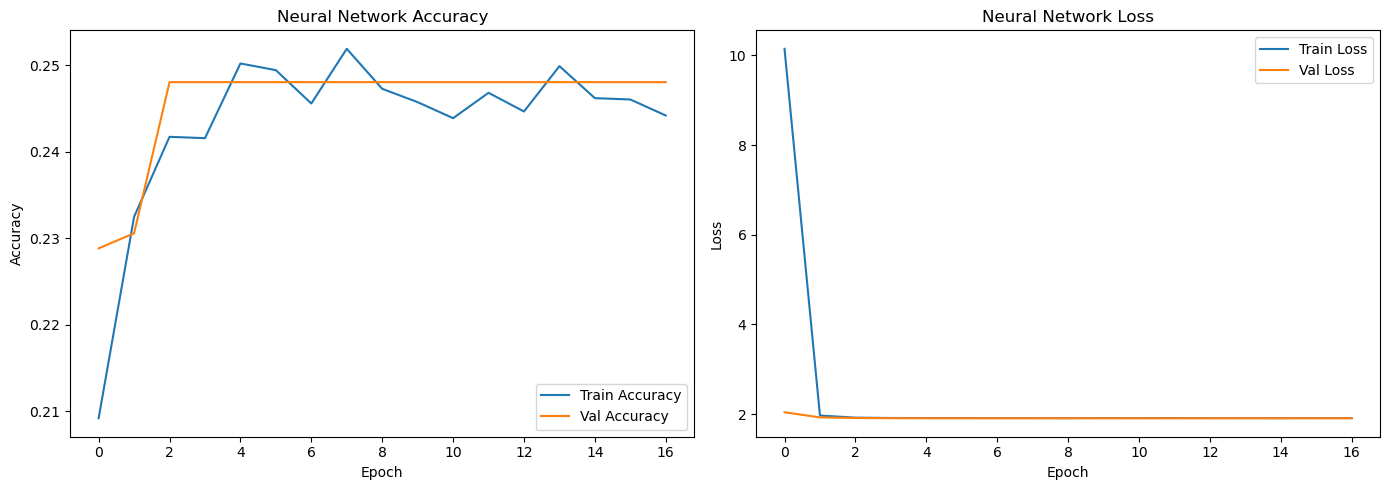

  Training history saved to: C:\Users\wldky\OneDrive - Montana Tech\Spring-2026\CSCI 447\ML Project\dataset\results\nn_training_history.png
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step 

Results: Neural Network (MLP)
  Exact accuracy:   24.8%
  Within 1 grade:   66.9%

Classification Report:
              precision    recall  f1-score   support

       PSA 1       0.00      0.00      0.00         7
       PSA 2       0.00      0.00      0.00         4
       PSA 3       0.00      0.00      0.00        56
       PSA 4       0.00      0.00      0.00        61
       PSA 5       0.00      0.00      0.00       131
       PSA 6       0.00      0.00      0.00        73
       PSA 7       0.00      0.00      0.00       264
       PSA 8       0.25      1.00      0.40       284
       PSA 9       0.00      0.00      0.00       218
      PSA 10       0.00      0.00      0.00        47

    accuracy                           0.25      1145
   macro avg       0.02      0.10      0.04      1145
weighted

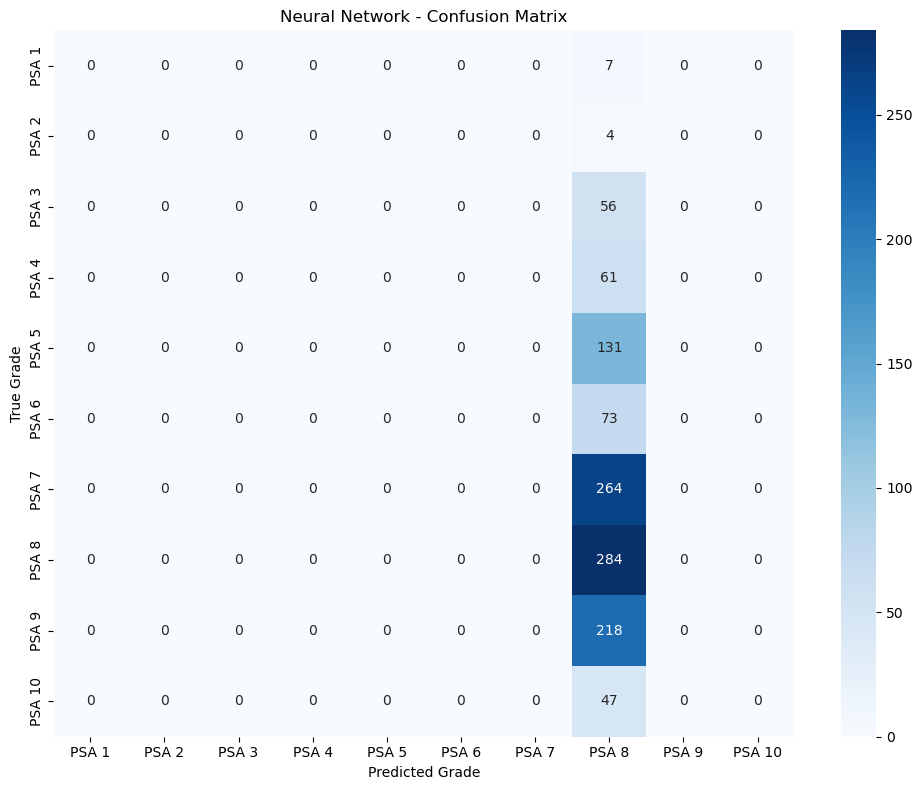

  Confusion matrix saved to: C:\Users\wldky\OneDrive - Montana Tech\Spring-2026\CSCI 447\ML Project\dataset\results\nn_confusion.png

Final Model Comparison
Model                     Exact Acc       Within 1 Grade 
-------------------------------------------------------
RF Classifier             51.0            76.3           
PCA + SVM                 52.9            75.0           
RF Regressor              28.2            72.2           
Neural Network            24.8            66.9           


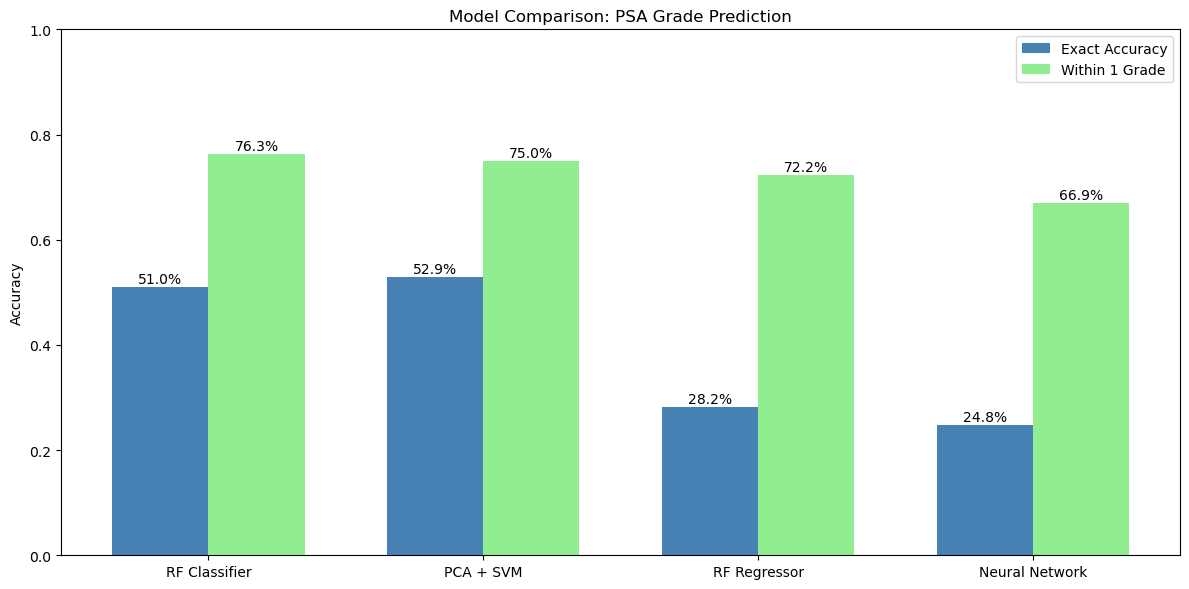

Comparison chart saved to: C:\Users\wldky\OneDrive - Montana Tech\Spring-2026\CSCI 447\ML Project\dataset\results\model_comparison.png

All done! Check your results folder for charts.


In [15]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load data
X_train, X_val, X_test, y_train, y_val, y_test = load_data(DATASET_PATH)

# Neural network labels need to be 0-indexed (0-9 instead of 1-10)
y_train_nn = y_train - 1
y_val_nn   = y_val   - 1
y_test_nn  = y_test  - 1

results = []

# ── Model 1: Random Forest Classifier ─────────────────────────────────────
print(f"\n{'='*45}")
print("Training Random Forest Classifier...")
print("(This may take a few minutes)")
rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=1
)
rf_clf.fit(X_train, y_train)
rf_clf_preds = rf_clf.predict(X_test)
acc, w1 = evaluate_classifier("Random Forest Classifier", y_test, rf_clf_preds)
plot_confusion_matrix(
    y_test, rf_clf_preds,
    "Random Forest Classifier - Confusion Matrix",
    "rf_classifier_confusion.png"
)
results.append({'name': 'RF Classifier', 'accuracy': acc, 'within_one': w1})

# ── Model 2: PCA + SVM Classifier ─────────────────────────────────────────
print(f"\n{'='*45}")
print(f"Training PCA ({PCA_COMPONENTS} components) + SVM Classifier...")
print("(This will take longer — SVM is slow on large datasets)")
pca_svm = Pipeline([
    ('pca', PCA(n_components=PCA_COMPONENTS, random_state=RANDOM_SEED)),
    ('svm', SVC(kernel='rbf', C=10, gamma='scale', random_state=RANDOM_SEED))
])
pca_svm.fit(X_train, y_train)
svm_preds = pca_svm.predict(X_test)
acc, w1 = evaluate_classifier("PCA + SVM Classifier", y_test, svm_preds)
plot_confusion_matrix(
    y_test, svm_preds,
    "PCA + SVM Classifier - Confusion Matrix",
    "svm_confusion.png"
)
results.append({'name': 'PCA + SVM', 'accuracy': acc, 'within_one': w1})

# ── Model 3: PCA + Random Forest Regressor ────────────────────────────────
print(f"\n{'='*45}")
print(f"Training PCA ({PCA_COMPONENTS} components) + Random Forest Regressor...")
print("(PCA reduces features first so this runs much faster)")

# Reuse the PCA already fit on the training data from the SVM step
# so we don't have to recompute it
X_train_pca = pca_svm.named_steps['pca'].transform(X_train)
X_test_pca  = pca_svm.named_steps['pca'].transform(X_test)

rf_reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=1
)
rf_reg.fit(X_train_pca, y_train)
rf_reg_preds_raw              = rf_reg.predict(X_test_pca)
rf_reg_preds_rounded, acc, w1 = evaluate_regressor("PCA + RF Regressor", y_test, rf_reg_preds_raw)
plot_confusion_matrix(
    y_test, rf_reg_preds_rounded,
    "Random Forest Regressor - Confusion Matrix",
    "rf_regressor_confusion.png"
)
results.append({'name': 'RF Regressor', 'accuracy': acc, 'within_one': w1})

# ── Model 4: Neural Network ────────────────────────────────────────────────
print(f"\n{'='*45}")
print("Training Neural Network (MLP)...")
print("(Uses validation set for early stopping)")

input_dim = X_train.shape[1]
nn_model  = build_neural_network(input_dim)
nn_model.summary()

# Early stopping stops training if val loss stops improving
# This prevents overfitting and saves time
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,           # stop after 5 epochs with no improvement
    restore_best_weights=True
)

history = nn_model.fit(
    X_train, y_train_nn,
    epochs=NN_EPOCHS,
    batch_size=NN_BATCH_SIZE,
    validation_data=(X_val, y_val_nn),
    callbacks=[early_stopping],
    verbose=1
)

# Plot training history
plot_training_history(history, "nn_training_history.png")

# Evaluate
nn_preds_proba = nn_model.predict(X_test)
nn_preds       = np.argmax(nn_preds_proba, axis=1) + 1  # convert back to 1-10
acc, w1        = evaluate_classifier("Neural Network (MLP)", y_test, nn_preds)
plot_confusion_matrix(
    y_test, nn_preds,
    "Neural Network - Confusion Matrix",
    "nn_confusion.png"
)
results.append({'name': 'Neural Network', 'accuracy': acc, 'within_one': w1})

# ── Final Comparison ───────────────────────────────────────────────────────
print(f"\n{'='*55}")
print("Final Model Comparison")
print(f"{'='*55}")
print(f"{'Model':<25} {'Exact Acc':<15} {'Within 1 Grade':<15}")
print(f"{'-'*55}")
for r in results:
    print(f"{r['name']:<25} {r['accuracy']*100:<15.1f} {r['within_one']*100:<15.1f}")
print(f"{'='*55}")

plot_model_comparison(results)
print("\nAll done! Check your results folder for charts.")